In [123]:
!pip install catboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 11.0 MB/s eta 0:00:10
   - -------------------------------------- 3.7/101.7 MB 9.8 MB/s eta 0:00:10
   -- ------------------------------------- 6.3/101.7 MB 10.5 MB/s eta 0:00:10
   --- ------------------------------------ 8.4/101.7 MB 10.5 MB/s eta 0:00:09
   ---- ----------------------------------- 10.5/101.7 MB 10.4 MB/s eta 0:00:09
   ----- ---------------------------------- 12.8/101.7 MB 10.4 MB/s eta 0:00:09
   ----- ---------------------------------- 15.2/101.7 MB 10.5 MB/s eta 0:00:09
   ------ --------------------------------- 17.3/101.7 MB 10.5 MB/s eta 0:00:09
   ------- -------------------------------- 18.9/101.7 MB 10.1 MB/s eta 0:00:09
   -------- ------------------------------- 21.2/101.7 MB 10.3 MB/s eta 0:00:08
   --------- ------------------------------ 23.6/101.7 MB 10.3 MB/s eta 0:00:08
   --------- ------------------------------ 25.4/101.7


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [124]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours as ENN
from imblearn.pipeline import Pipeline as IMBPipeline

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve, auc)

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split


In [77]:
X_train = pd.read_parquet('X_train_final.parquet')
X_test = pd.read_parquet('X_test_final.parquet')
y_train = pd.read_parquet('y_train_final.parquet').iloc[:, 0] # Возвращаем в Series
y_test = pd.read_parquet('y_test_final.parquet').iloc[:, 0]

In [78]:
#Дисбаланс классов - подготовим еще два набора данных , сделанных на основе наших train  данных, методами Under- и OverSampling
y_train.value_counts(normalize=True)

Response
0    0.876596
1    0.123404
Name: proportion, dtype: float64

In [79]:
pipeline_Tomek_ENN = IMBPipeline([
                            ('ENN', ENN(sampling_strategy='majority')),
                            ('tomek', TomekLinks(sampling_strategy='majority'))
                                ])
X_train_Tomek_ENN, y_train_Tomek_ENN = pipeline_Tomek_ENN.fit_resample(X_train, y_train)


pipeline_Tomek_Smote = IMBPipeline([
                            ('smote', SMOTE(sampling_strategy='auto',k_neighbors=10, random_state=42)),
                            ('tomek', TomekLinks(sampling_strategy='majority'))
                                   ])
X_train_Tomek_Smote, y_train_Tomek_Smote = pipeline_Tomek_Smote.fit_resample(X_train, y_train)

mpl.style.use('ggplot')

In [80]:
y_train_Tomek_ENN.value_counts(normalize=True)

Response
0    0.843225
1    0.156775
Name: proportion, dtype: float64

In [81]:
y_train_Tomek_Smote.value_counts(normalize=True)

Response
1    0.515238
0    0.484762
Name: proportion, dtype: float64

Будем проверять качество моделей на этих трех типах данных(X_train, y_train / X_train_Tomek_Smote, y_train_Tomek_Smote / X_train_Tomek_ENN, y_train_Tomek_ENN).
---

In [82]:
#Создаем функцию для обучения моделей и записи основных метрик качества в отдельную таблицу, для удобства отслеживания - в конце взглянем на полученные метрики и отсеем переобучившиеся модели.
results_table = []
def model_prediction(model, X_tr, y_tr, X_ts, y_ts, experiment_name):
    model.fit(X_tr, y_tr)
    

    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_ts)
    if 'SVC' not in experiment_name:
        y_test_prob = model.predict_proba(X_ts)[:, 1]

    metrics = {
        'Experiment': experiment_name,
        'Train_Acc': accuracy_score(y_tr, y_train_pred),
        'Test_Acc': accuracy_score(y_ts, y_test_pred),
        'Precision': precision_score(y_ts, y_test_pred),
        'Recall': recall_score(y_ts, y_test_pred),
        'F1_Score': f1_score(y_ts, y_test_pred)
        
    }
    if 'y_test_prob' in locals():
        metrics['ROC_AUC'] = roc_auc_score(y_ts, y_test_prob)
    else:
        metrics['ROC_AUC'] = None
    
    results_table.append(metrics)
    print(model.best_params_)
    cm = confusion_matrix(y_ts, y_test_pred)
    if 'y_test_prob' in locals():
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        sns.heatmap(cm, annot=True, fmt="g", cmap="Greens", ax=axes[0])
        axes[0].set_title(f"Модель: {experiment_name}")
    
        precision, recall, threesholds = precision_recall_curve(y_ts, y_test_prob)
        pr_auc = auc(recall, precision)
        axes[1].plot(recall, precision, color='blue', label=f'PR AUC = {pr_auc:.3f}')
        axes[1].set_title(f'Presision-Recall curve {experiment_name}')
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        axes[1].legend(loc="lower left")
    else:
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="g", cmap="Greens")
        plt.title(f"Confusion Matrix: {experiment_name}")
        plt.show()
    
    
    plt.show()
    print(classification_report(y_ts, y_test_pred))


In [83]:
pipeline_LR = IMBPipeline([
                        ('scaler', StandardScaler()),
                        ('classifier', LogisticRegression(max_iter=1001, class_weight='balanced'))
                        ])

grid_params = {
               'classifier__C': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
               
              }

grid_LR = RandomizedSearchCV(
                            estimator=pipeline_LR,
                            param_distributions=grid_params,
                            cv=5,
                            scoring='roc_auc',
                            n_jobs=1,
                            verbose=1
                            )

c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 6 candidates, totalling 30 fits
{'classifier__C': 1.0}


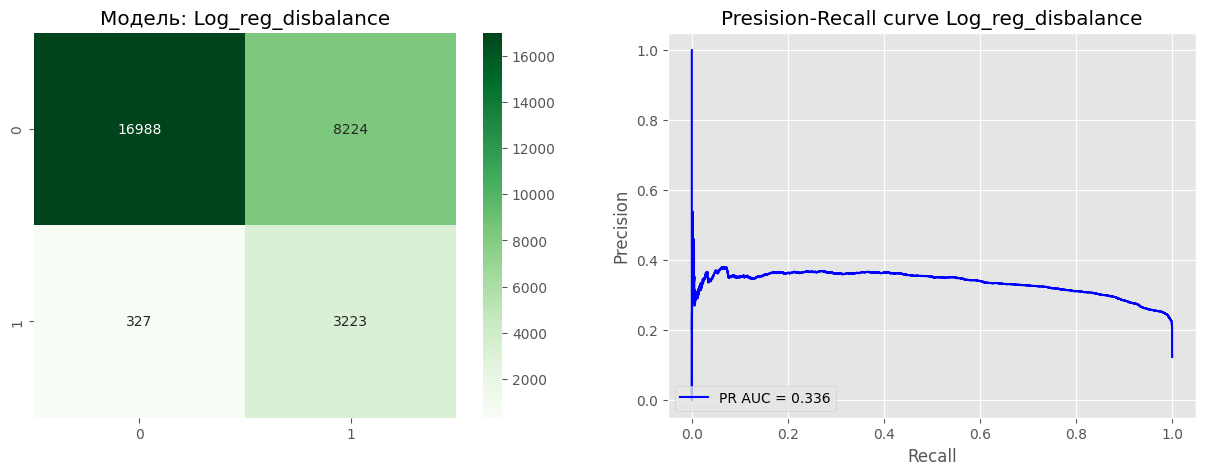

              precision    recall  f1-score   support

           0       0.98      0.67      0.80     25212
           1       0.28      0.91      0.43      3550

    accuracy                           0.70     28762
   macro avg       0.63      0.79      0.61     28762
weighted avg       0.89      0.70      0.75     28762



In [84]:
model_prediction(model=grid_LR, X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test, experiment_name='Log_reg_disbalance')

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__C': 1.0}


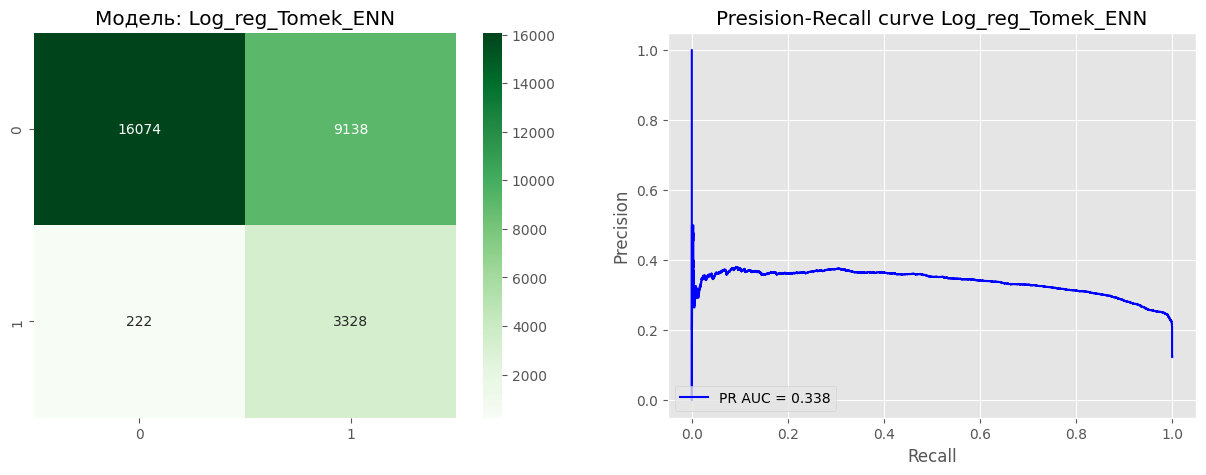

              precision    recall  f1-score   support

           0       0.99      0.64      0.77     25212
           1       0.27      0.94      0.42      3550

    accuracy                           0.67     28762
   macro avg       0.63      0.79      0.60     28762
weighted avg       0.90      0.67      0.73     28762



In [85]:
model_prediction(model=grid_LR, X_tr=X_train_Tomek_ENN, y_tr= y_train_Tomek_ENN, X_ts=X_test, y_ts=y_test, experiment_name='Log_reg_Tomek_ENN')

In [86]:
#Уберем class_weight='balanced', так как SMOTE сделал синтетические данные и по сути дисбаланса класса в этих обучающих данных не будет
pipeline_LR_smote = IMBPipeline([
                        ('scaler', StandardScaler()),
                        ('classifier', LogisticRegression(max_iter=1001))
                        ])          

grid_LR_smote = RandomizedSearchCV(
                            estimator=pipeline_LR_smote,
                            param_distributions=grid_params,
                            cv=5,
                            scoring='roc_auc',
                            n_jobs=1,
                            verbose=1
                            )

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__C': 1.0}


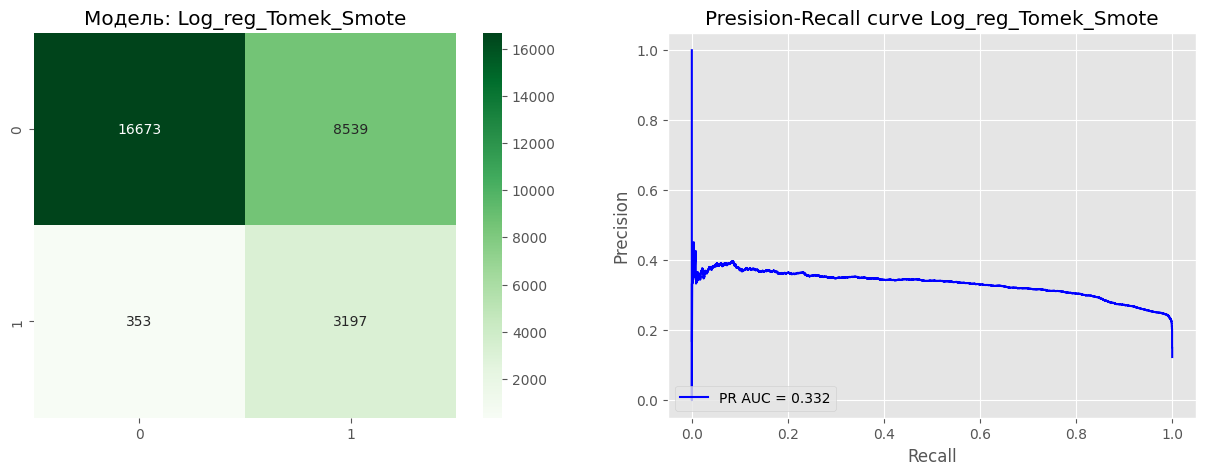

              precision    recall  f1-score   support

           0       0.98      0.66      0.79     25212
           1       0.27      0.90      0.42      3550

    accuracy                           0.69     28762
   macro avg       0.63      0.78      0.60     28762
weighted avg       0.89      0.69      0.74     28762



In [87]:
model_prediction(model=grid_LR_smote, X_tr=X_train_Tomek_Smote, y_tr= y_train_Tomek_Smote, X_ts=X_test, y_ts=y_test, experiment_name='Log_reg_Tomek_Smote')

Исходя из контекста задачи, которая решается - задетектить по максимуму наших клиентов, которые потенциально, положительно отреагируют на преждложение, найти их по максимуму. Случаи, когда модель будет ошибочно принимать 0 за 1 можно не считать чем-то ужасным. Так же важно проверять,чтоб  Sampling модели не переобучились. Посмотрим на это в конце эксперимента, оставив в финальном датасете ['Train_Acc'] - ['Test_Acc'] <0.1
----

-----
SVC - метод опорных векторов
---

In [88]:
pipeline_SVC_linear = IMBPipeline([
                        ('scaler', StandardScaler()),
                        ('classifier', LinearSVC(max_iter=3000))
                        ])   
grid_params_SVC = {
                   'classifier__C': [0.001, 0.1, 2],
                   'classifier__class_weight': [None, 'balanced']                                                    
                  }

grid_SVC_linear = RandomizedSearchCV(estimator=pipeline_SVC_linear, param_distributions=grid_params_SVC, cv=5,
                                     scoring='f1', n_jobs=-1, verbose=1)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__class_weight': 'balanced', 'classifier__C': 0.1}


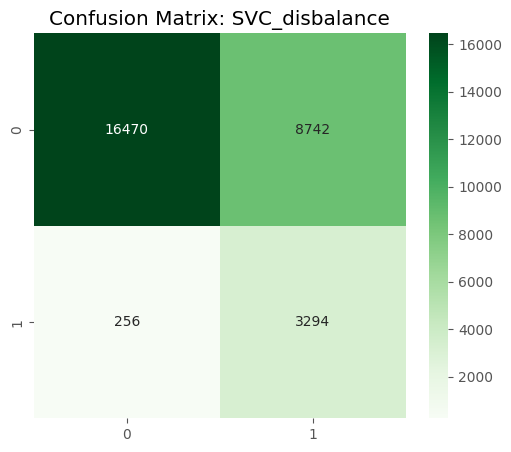

              precision    recall  f1-score   support

           0       0.98      0.65      0.79     25212
           1       0.27      0.93      0.42      3550

    accuracy                           0.69     28762
   macro avg       0.63      0.79      0.60     28762
weighted avg       0.90      0.69      0.74     28762



In [89]:
model_prediction(model=grid_SVC_linear, X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test, experiment_name='SVC_disbalance')

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__class_weight': 'balanced', 'classifier__C': 2}


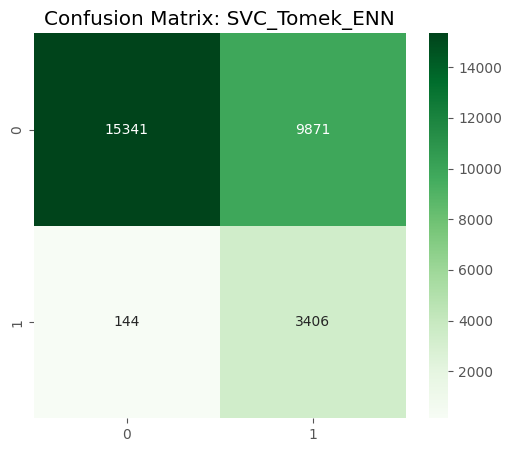

              precision    recall  f1-score   support

           0       0.99      0.61      0.75     25212
           1       0.26      0.96      0.40      3550

    accuracy                           0.65     28762
   macro avg       0.62      0.78      0.58     28762
weighted avg       0.90      0.65      0.71     28762



In [90]:
model_prediction(model=grid_SVC_linear, X_tr=X_train_Tomek_ENN, y_tr= y_train_Tomek_ENN, X_ts=X_test, y_ts=y_test, experiment_name='SVC_Tomek_ENN')

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'classifier__class_weight': None, 'classifier__C': 0.1}


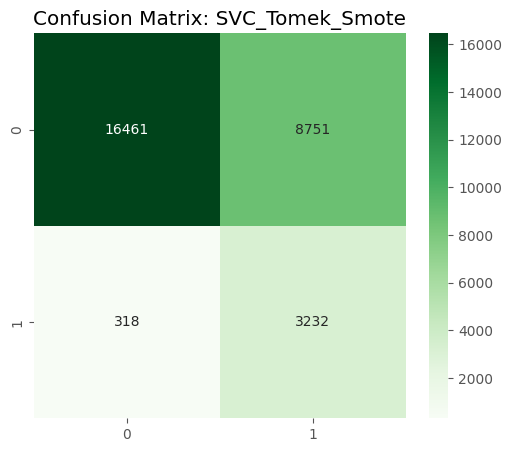

              precision    recall  f1-score   support

           0       0.98      0.65      0.78     25212
           1       0.27      0.91      0.42      3550

    accuracy                           0.68     28762
   macro avg       0.63      0.78      0.60     28762
weighted avg       0.89      0.68      0.74     28762



In [91]:
model_prediction(model=grid_SVC_linear, X_tr=X_train_Tomek_Smote, y_tr= y_train_Tomek_Smote, X_ts=X_test, y_ts=y_test, experiment_name='SVC_Tomek_Smote')

----------

In [92]:
#Посмотрим как ДеревоРешений справится с построением модели 
pipeline_DT = IMBPipeline([('scaler', StandardScaler()),    
                            ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=0))]
                            )

param_grid_DT = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [15,18,22,25],
    'classifier__min_samples_split': [2, 3, 5],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__max_features': ['sqrt'],
    'classifier__ccp_alpha': [0.001, 0.0001, 0.005]
                }
grid_DT = RandomizedSearchCV(
    estimator=pipeline_DT,
    param_distributions=param_grid_DT,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
        )

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 15, 'classifier__criterion': 'gini', 'classifier__ccp_alpha': 0.0001}


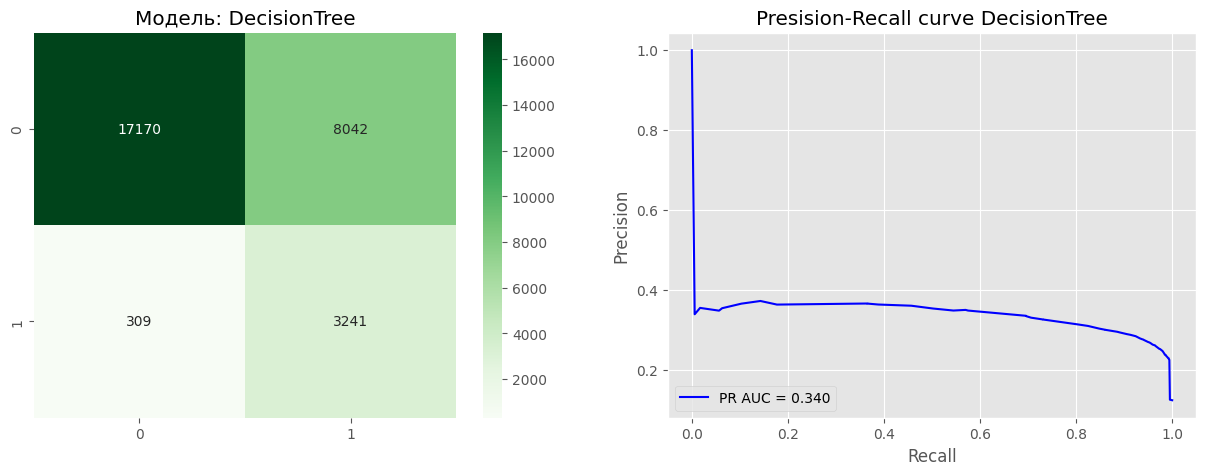

              precision    recall  f1-score   support

           0       0.98      0.68      0.80     25212
           1       0.29      0.91      0.44      3550

    accuracy                           0.71     28762
   macro avg       0.63      0.80      0.62     28762
weighted avg       0.90      0.71      0.76     28762



In [93]:
model_prediction(model=grid_DT, X_tr=X_train, y_tr= y_train, X_ts=X_test, y_ts=y_test, experiment_name='DecisionTree')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 22, 'classifier__criterion': 'entropy', 'classifier__ccp_alpha': 0.001}


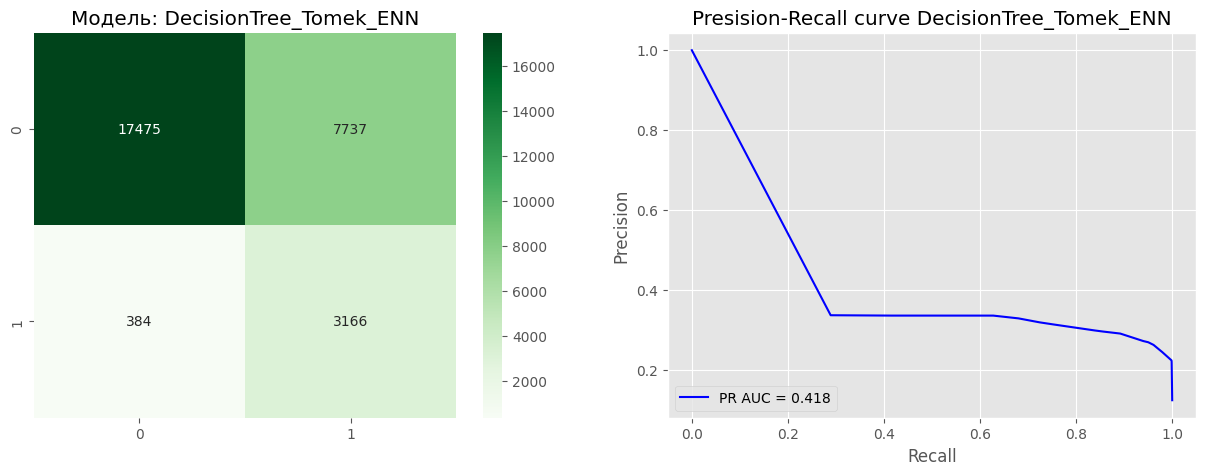

              precision    recall  f1-score   support

           0       0.98      0.69      0.81     25212
           1       0.29      0.89      0.44      3550

    accuracy                           0.72     28762
   macro avg       0.63      0.79      0.62     28762
weighted avg       0.89      0.72      0.77     28762



In [94]:
model_prediction(model=grid_DT, X_tr=X_train_Tomek_ENN, y_tr=y_train_Tomek_ENN, X_ts=X_test, y_ts=y_test, experiment_name='DecisionTree_Tomek_ENN')

In [95]:
df_results = pd.DataFrame(results_table)
df_results.sort_values(by='Recall', ascending=False, inplace=True)
df_results

,Experiment,Train_Acc,Test_Acc,Precision,Recall,F1_Score,ROC_AUC
4,SVC_Tomek_ENN,0.786555,0.651798,0.256534,0.959437,0.404826,NaN
1,Log_reg_Tomek_ENN,0.805268,0.674571,0.266966,0.937465,0.415584,0.848335
3,SVC_disbalance,0.692465,0.687157,0.273679,0.927887,0.422687,NaN
6,DecisionTree,0.715979,0.709652,0.287246,0.912958,0.436999,0.846638
5,SVC_Tomek_Smote,0.825990,0.684688,0.269715,0.910423,0.416146,NaN
0,Log_reg_disbalance,0.708921,0.702698,0.281558,0.907887,0.429819,0.847615
2,Log_reg_Tomek_Smote,0.826624,0.690842,0.272410,0.900563,0.418291,0.841440
7,DecisionTree_Tomek_ENN,0.845831,0.717648,0.290379,0.891831,0.438110,0.841472


In [96]:
from sklearn.ensemble import RandomForestClassifier

In [97]:
pipeline_RF = IMBPipeline([('scaler', StandardScaler()),    
                            ('classifier', RandomForestClassifier(random_state=15, bootstrap=True))]
                            )

param_grid_RF = {
    'classifier__n_estimators': [200, 300],
    'classifier__max_depth': [ 12, 15, 20],
    'classifier__min_samples_split': [3, 5, 7],
    'classifier__min_samples_leaf': [ 10, 20],
    'classifier__max_features': ['sqrt'],
    'classifier__ccp_alpha': [0.001, 0.01],
    'classifier__max_samples': [0.7, 0.9],
    'classifier__class_weight': ['balanced', 'balanced_subsample']   
}

grid_RF = RandomizedSearchCV(
    estimator=pipeline_RF,
    param_distributions=param_grid_RF,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
        )

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 3, 'classifier__min_samples_leaf': 20, 'classifier__max_samples': 0.7, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 20, 'classifier__class_weight': 'balanced_subsample', 'classifier__ccp_alpha': 0.001}


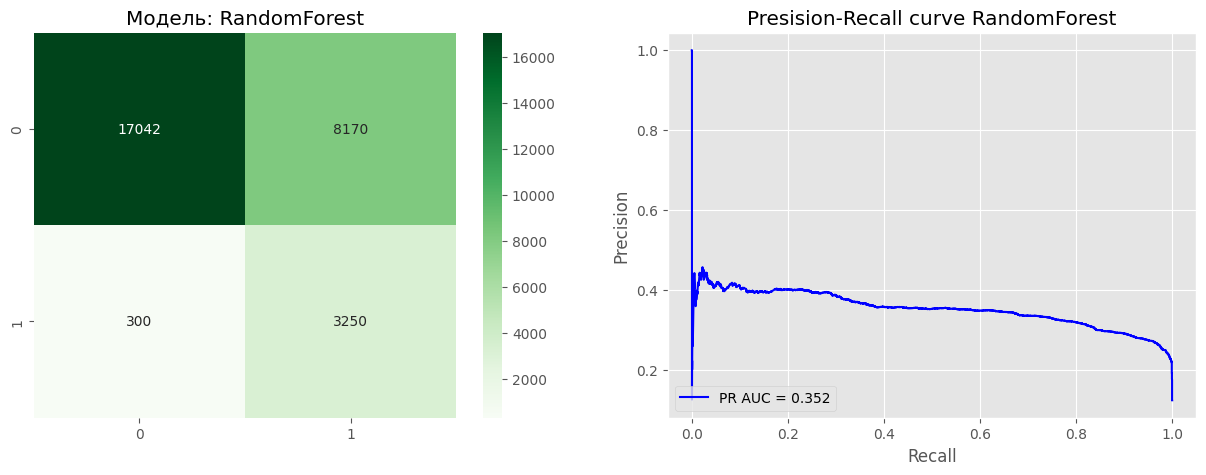

              precision    recall  f1-score   support

           0       0.98      0.68      0.80     25212
           1       0.28      0.92      0.43      3550

    accuracy                           0.71     28762
   macro avg       0.63      0.80      0.62     28762
weighted avg       0.90      0.71      0.76     28762



In [98]:
model_prediction(model=grid_RF, X_tr=X_train, y_tr= y_train, X_ts=X_test, y_ts=y_test, experiment_name='RandomForest')

In [99]:
param_grid_RF_1 = {
    'classifier__n_estimators': [200, 300],
    'classifier__max_depth': [ 12, 15, 20],
    'classifier__min_samples_split': [3, 5, 7],
    'classifier__min_samples_leaf': [ 10, 20],
    'classifier__max_features': ['sqrt'],
    'classifier__ccp_alpha': [0.001, 0.01],
    'classifier__max_samples': [0.7, 0.8, 0.9],
    'classifier__class_weight': [None]   #Убираем балансировку , так как планируем подавать данные сэмплированные
}

grid_RF_1 = RandomizedSearchCV(
    estimator=pipeline_RF,
    param_distributions=param_grid_RF_1,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
        )

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 3, 'classifier__min_samples_leaf': 20, 'classifier__max_samples': 0.8, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 12, 'classifier__class_weight': None, 'classifier__ccp_alpha': 0.001}


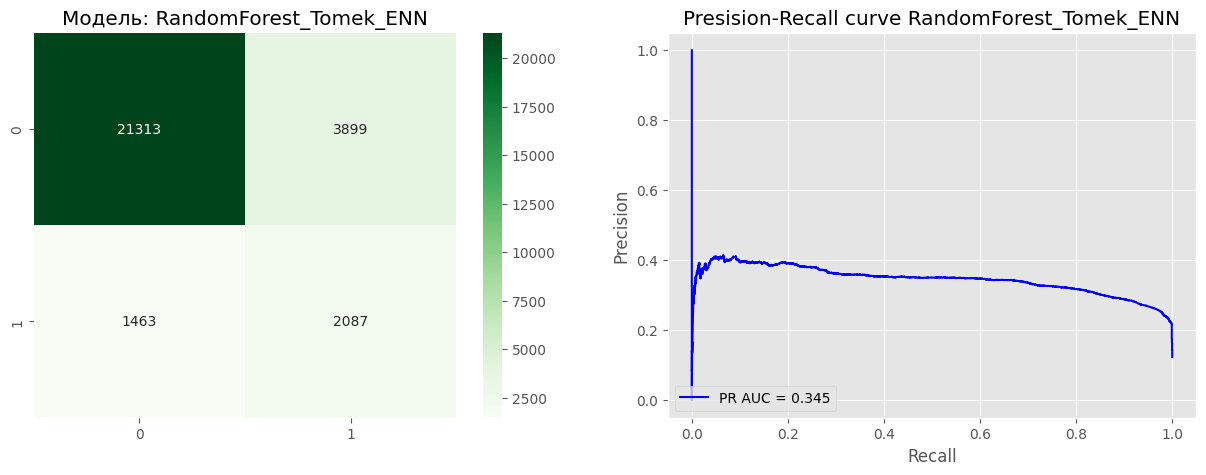

              precision    recall  f1-score   support

           0       0.94      0.85      0.89     25212
           1       0.35      0.59      0.44      3550

    accuracy                           0.81     28762
   macro avg       0.64      0.72      0.66     28762
weighted avg       0.86      0.81      0.83     28762



In [100]:
model_prediction(model=grid_RF_1, X_tr=X_train_Tomek_ENN, y_tr= y_train_Tomek_ENN, X_ts=X_test, y_ts=y_test, experiment_name='RandomForest_Tomek_ENN')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 7, 'classifier__min_samples_leaf': 10, 'classifier__max_samples': 0.7, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 20, 'classifier__class_weight': None, 'classifier__ccp_alpha': 0.001}


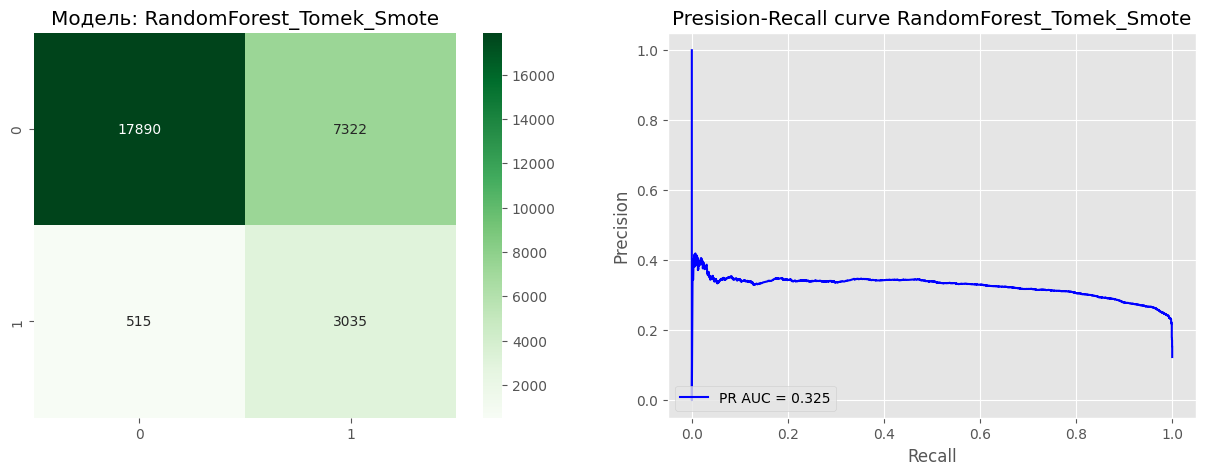

              precision    recall  f1-score   support

           0       0.97      0.71      0.82     25212
           1       0.29      0.85      0.44      3550

    accuracy                           0.73     28762
   macro avg       0.63      0.78      0.63     28762
weighted avg       0.89      0.73      0.77     28762



In [101]:
model_prediction(model=grid_RF_1, X_tr=X_train_Tomek_Smote, y_tr= y_train_Tomek_Smote, X_ts=X_test, y_ts=y_test, experiment_name='RandomForest_Tomek_Smote')

In [102]:
df_results = pd.DataFrame(results_table)
df_results.sort_values(by='Recall', ascending=False, inplace=True)
df_results 

,Experiment,Train_Acc,Test_Acc,Precision,Recall,F1_Score,ROC_AUC
4,SVC_Tomek_ENN,0.786555,0.651798,0.256534,0.959437,0.404826,NaN
1,Log_reg_Tomek_ENN,0.805268,0.674571,0.266966,0.937465,0.415584,0.848335
3,SVC_disbalance,0.692465,0.687157,0.273679,0.927887,0.422687,NaN
8,RandomForest,0.708771,0.705514,0.284588,0.915493,0.434202,0.852156
6,DecisionTree,0.715979,0.709652,0.287246,0.912958,0.436999,0.846638
5,SVC_Tomek_Smote,0.825990,0.684688,0.269715,0.910423,0.416146,NaN
0,Log_reg_disbalance,0.708921,0.702698,0.281558,0.907887,0.429819,0.847615
2,Log_reg_Tomek_Smote,0.826624,0.690842,0.272410,0.900563,0.418291,0.841440
7,DecisionTree_Tomek_ENN,0.845831,0.717648,0.290379,0.891831,0.438110,0.841472
10,RandomForest_Tomek_Smote,0.838640,0.727522,0.293039,0.854930,0.436471,0.841940


----
----

Бустинг - попробуем модель XGBClassifier
---

In [103]:
pipeline_XGB = IMBPipeline([('scaler', StandardScaler()),    
                            ('classifier', XGBClassifier(objective='binary:logistic'))]
                            )

param_grid_XGB = {
    'classifier__n_estimators': [ 400, 600, 800],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [5, 8, 10],
    'classifier__min_child_weight': [1, 5, 10],
    'classifier__gamma': [0, 0.1, 0.2],
    'classifier__subsample': [0.7, 0.9],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9],
    'classifier__reg_alpha': [0, 0.01, 0.1],
    'classifier__reg_lambda': [1, 5, 10],
    'classifier__scale_pos_weight': [5, 8] # Компенсируем дисбаланс классов, заставив момдель на веса с учетом дб

       
}

grid_XGB = RandomizedSearchCV(
    estimator=pipeline_XGB,
    n_iter=50, 
    param_distributions=param_grid_XGB,
    scoring='average_precision',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=15
        )

Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'classifier__subsample': 0.9, 'classifier__scale_pos_weight': 8, 'classifier__reg_lambda': 5, 'classifier__reg_alpha': 0.01, 'classifier__n_estimators': 800, 'classifier__min_child_weight': 1, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.05, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.7}


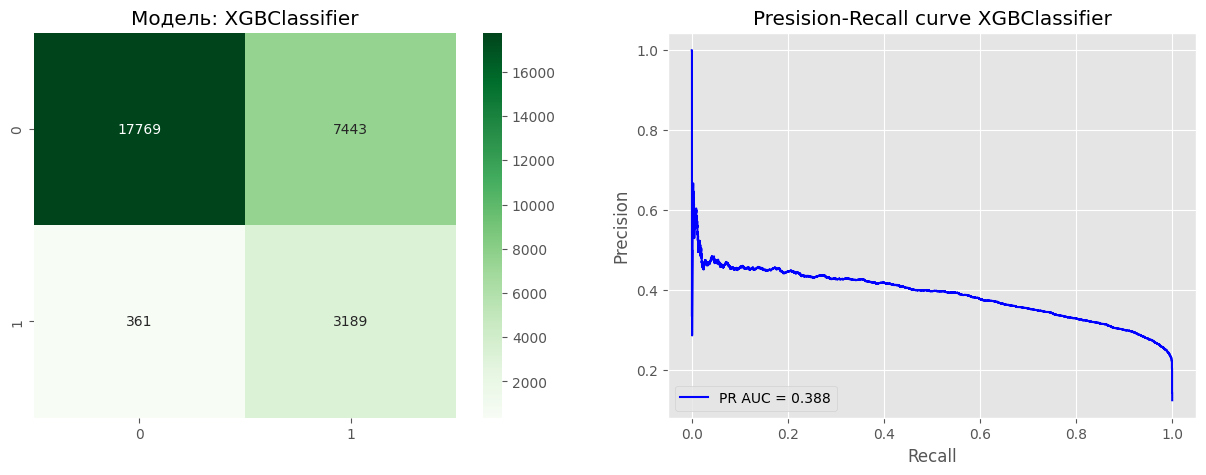

              precision    recall  f1-score   support

           0       0.98      0.70      0.82     25212
           1       0.30      0.90      0.45      3550

    accuracy                           0.73     28762
   macro avg       0.64      0.80      0.63     28762
weighted avg       0.90      0.73      0.77     28762



In [104]:
model_prediction(model=grid_XGB, X_tr=X_train, y_tr= y_train, X_ts=X_test, y_ts=y_test, experiment_name='XGBClassifier')

In [107]:
df_results = pd.DataFrame(results_table)
df_results.sort_values(by='Recall', ascending=False, inplace=True)
df_results

,Experiment,Train_Acc,Test_Acc,Precision,Recall,F1_Score,ROC_AUC
4,SVC_Tomek_ENN,0.786555,0.651798,0.256534,0.959437,0.404826,NaN
1,Log_reg_Tomek_ENN,0.805268,0.674571,0.266966,0.937465,0.415584,0.848335
3,SVC_disbalance,0.692465,0.687157,0.273679,0.927887,0.422687,NaN
8,RandomForest,0.708771,0.705514,0.284588,0.915493,0.434202,0.852156
6,DecisionTree,0.715979,0.709652,0.287246,0.912958,0.436999,0.846638
5,SVC_Tomek_Smote,0.825990,0.684688,0.269715,0.910423,0.416146,NaN
0,Log_reg_disbalance,0.708921,0.702698,0.281558,0.907887,0.429819,0.847615
2,Log_reg_Tomek_Smote,0.826624,0.690842,0.272410,0.900563,0.418291,0.841440
11,XGBClassifier,0.744559,0.728670,0.299944,0.898310,0.449725,0.865357
7,DecisionTree_Tomek_ENN,0.845831,0.717648,0.290379,0.891831,0.438110,0.841472


Все модели, которые обучались на Сэмплированных данных показывают сильное переобучение.

In [109]:
#Будем смотреть только на непереобучившиеся модели.
mask = df_results['Train_Acc'] - df_results['Test_Acc']
df_results[mask <= 0.07]

,Experiment,Train_Acc,Test_Acc,Precision,Recall,F1_Score,ROC_AUC
3,SVC_disbalance,0.692465,0.687157,0.273679,0.927887,0.422687,NaN
8,RandomForest,0.708771,0.705514,0.284588,0.915493,0.434202,0.852156
6,DecisionTree,0.715979,0.709652,0.287246,0.912958,0.436999,0.846638
0,Log_reg_disbalance,0.708921,0.702698,0.281558,0.907887,0.429819,0.847615
11,XGBClassifier,0.744559,0.728670,0.299944,0.898310,0.449725,0.865357
9,RandomForest_Tomek_ENN,0.881889,0.813573,0.348647,0.587887,0.437710,0.849960


 1. Видим, что максимальный охват на данный момент показывает моедль SVC_disbalance(Линейная модель опорных векторов, в которую подавались разбалансированные данные и использовался class_weight='balanced'). Модель находит 92.8% всех потенциальных клиентов, при этом конечно сама ихкая точность

 2. Можно выбрать путь - RandomForest_Tomek_ENN, в два раза меньше выбранных клиентов , как потениальных покупателей, но выше точность/ПОТЕРЯ 40%  реальных.

 3. Оптимальный вариант - XGBClassifier, все еще высокий охват - около 90%, но уже эффективнее SVC - самый высокие ROC_AUC и PR_AUC при явном указании модели, что присутствует дисбаланс классов.

------
------

CatBoostClassifier
---

In [120]:
#Подгрузим данные заново, чтобы вернуть прежний вид категориальных признаков и воспользоваться фичами CatBoostClassifier, которая принимает такие признаки и выжать больше из их "преобразования" своиими методами.

data = pd.read_csv(r'C:\Users\tsyto\Downloads\playground-series-s4e7\train.csv').sample(frac=0.01, random_state=11)
data['Annual_Premium_log'] = np.log1p(data['Annual_Premium'])
data.drop(['id'],axis =1, inplace=True)
data['Policy_Sales_Channel'] = data['Policy_Sales_Channel'].astype('str')
data['Region_Code'] = data['Region_Code'].astype('str')
y = data['Response']
X = data.drop(['Response'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=12, stratify=y)

In [121]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115048 entries, 10879447 to 4090682
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                115048 non-null  object 
 1   Age                   115048 non-null  int64  
 2   Driving_License       115048 non-null  int64  
 3   Region_Code           115048 non-null  object 
 4   Previously_Insured    115048 non-null  int64  
 5   Vehicle_Age           115048 non-null  object 
 6   Vehicle_Damage        115048 non-null  object 
 7   Annual_Premium        115048 non-null  float64
 8   Policy_Sales_Channel  115048 non-null  object 
 9   Vintage               115048 non-null  int64  
 10  Response              115048 non-null  int64  
 11  Annual_Premium_log    115048 non-null  float64
dtypes: float64(2), int64(5), object(5)
memory usage: 11.4+ MB


In [137]:
cat_features = tuple(['Gender', 'Vehicle_Age', 'Vehicle_Damage', 'Policy_Sales_Channel', 'Region_Code'])

In [138]:
catboost = CatBoostClassifier(random_state=10, verbose=False,
                              cat_features=cat_features, 
                              auto_class_weights='Balanced', bootstrap_type='Bernoulli',
                              one_hot_max_size=10, border_count=128)

catboost_pipeline = IMBPipeline([('classifier', catboost)])

param_grid_CB = {
                'classifier__iterations': [600, 800, 1000], 
                'classifier__learning_rate': [0.01, 0.03, 0.07, 0.1],
                'classifier__depth': [5, 6, 8, 10],
                'classifier__l2_leaf_reg': [1, 3, 5, 7],
                'classifier__subsample': [0.7, 0.9], 
                'classifier__random_strength': [1, 5, 10]
                }

grid_CB = RandomizedSearchCV(
                    estimator=catboost_pipeline,
                    param_distributions=param_grid_CB,
                    n_iter=50,
                    cv=4,
                    scoring='average_precision',
                    n_jobs=-1,
                    verbose=2,
                    random_state=9
                            )

Fitting 4 folds for each of 50 candidates, totalling 200 fits


c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tsyto\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\tsyto\AppData

{'classifier__subsample': 0.9, 'classifier__random_strength': 10, 'classifier__learning_rate': 0.07, 'classifier__l2_leaf_reg': 5, 'classifier__iterations': 1000, 'classifier__depth': 5}


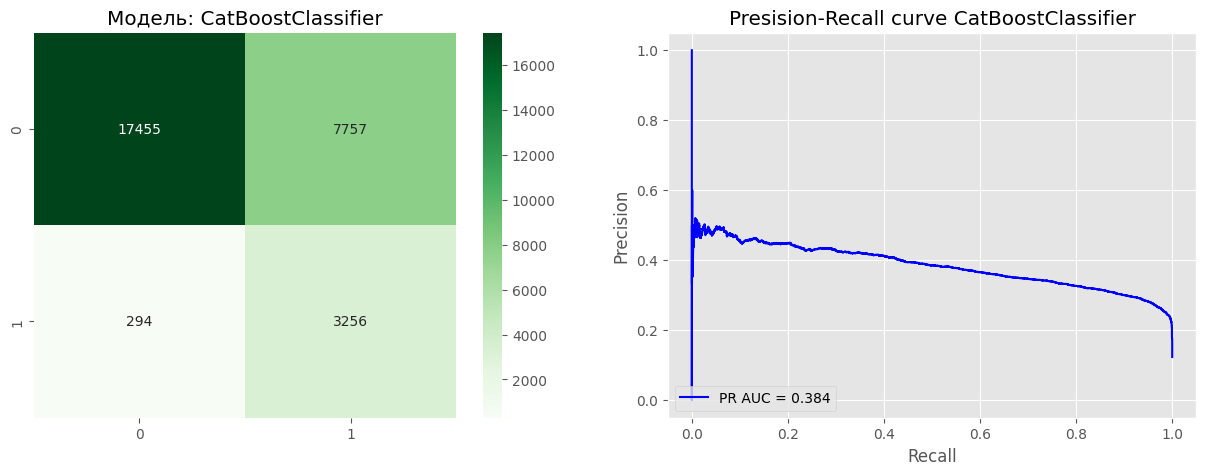

              precision    recall  f1-score   support

           0       0.98      0.69      0.81     25212
           1       0.30      0.92      0.45      3550

    accuracy                           0.72     28762
   macro avg       0.64      0.80      0.63     28762
weighted avg       0.90      0.72      0.77     28762



In [139]:
model_prediction(model=grid_CB, X_tr=X_train, y_tr= y_train, X_ts=X_test, y_ts=y_test, experiment_name='CatBoostClassifier')

In [ ]:
df_results = pd.DataFrame(results_table)
df_results.sort_values(by='Recall', ascending=False, inplace=True)
mask = df_results['Train_Acc'] - df_results['Test_Acc']
df_results[mask <= 0.07] #

,Experiment,Train_Acc,Test_Acc,Precision,Recall,F1_Score,ROC_AUC
3,SVC_disbalance,0.692465,0.687157,0.273679,0.927887,0.422687,NaN
12,CatBoostClassifier,0.728832,0.720082,0.295651,0.917183,0.447161,0.863731
8,RandomForest,0.708771,0.705514,0.284588,0.915493,0.434202,0.852156
6,DecisionTree,0.715979,0.709652,0.287246,0.912958,0.436999,0.846638
0,Log_reg_disbalance,0.708921,0.702698,0.281558,0.907887,0.429819,0.847615
11,XGBClassifier,0.744559,0.728670,0.299944,0.898310,0.449725,0.865357
9,RandomForest_Tomek_ENN,0.881889,0.813573,0.348647,0.587887,0.437710,0.849960


 - CatBoostClassifier все таки лучшая модель для наших задач, так как она вобрала(приблизилась) ко всем лучшим показателям метрик у других моделей:
высокий Precision(чуть-чуть не дотянула до XGBClassifier ) и высокий recall(чутка не дотянула до SVC_disbalance). От этого можем сказать, что хоть ROC_AUC и PR_AUC уступает на 0,004 и 0,002 соответственно XGBClassifier, но CatBoostClassifier круче, так как наша задача находить класс 1 в как можно большем количестве, а у CatBoostClassifier практически лучший recall без значительной потери Precision.

Взглянем на важность признаков, которые присвоила модель:

In [147]:
best_model = grid_CB.best_estimator_.named_steps['classifier']
importances = best_model.get_feature_importance()
feature_names = X_train.columns

df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
                  }).sort_values(by='Importance', ascending=False)
df


,Feature,Importance
4,Previously_Insured,47.734019
6,Vehicle_Damage,17.758146
9,Vintage,9.041553
1,Age,7.705956
8,Policy_Sales_Channel,6.280240
3,Region_Code,4.155234
7,Annual_Premium,3.648648
10,Annual_Premium_log,2.457796
5,Vehicle_Age,0.827462
0,Gender,0.292448


В нашем распределении важности признаков видим некоторые подтверждения нашего анализа из EDA части:
 - Previously_Insured и Vehicle_Damage перетягивают на себя огромную долю важности - в районе 65% "уверенности" модели.
 - Vintage оказывается что-то решает) хорошо, что не стали удалять, модель разглядела взаимосвязь. А вот Driving_License, кажется все таки можно было отбросить из-за малого представления.
 - забыли удалить Annual_Premium после логарифмирования, но есть информация, тчо Бустинги не боятся корреллирующих признаков... можно проссумировать их важность, чтобы оценить важность признака в целом.
 - Policy_Sales_Channel и Region_Code  - модель подтвердила выоскую значимость каналов связи и географии. Модель проводила свою проверку комбинаций категориальных признаков, выявляя "полезные закономерности" - вместо ручного target encoding задействовала все категориальные признаки.